# Graph of the content of GC

You should ensure wyou have biopython library installed. Use the following command in the python terminal to isntall it:

We will import SeqIO from BIO

In [2]:
from Bio import SeqIO

# Read the file
record = SeqIO.read("pBR322.fasta", "fasta")
sequence = record.seq
sequence 

Seq('TTCTCATGTTTGACAGCTTATCATCGATAAGCTTTAATGCGGTAGTTTATCACA...GAA')

We will read de description of the plasmid and its length.

In [ ]:
# for reading the description of the plasmid
record.id 

'J01749.1'

In [4]:
# for obtaining the total length of the sequence
len(sequence)

4361

We need to take a piece of the DNA and calculate the total sum of the guanines and citosines together. This is the formula:


$$
\text{GC Percentage} = \frac{\text{Number of 'G'} + \text{Number of 'C'}}{\text{Total sequence length}} \times 100
$$

$$
\text{GC\%} = \frac{\#G + \#C}{\text{Sequence Length}} \times 100
$$

In [11]:
num_g = sequence.count("G")
num_c = sequence.count("C")

print(f"Number of guanine: {num_g}")
print(f"Number of citosine: {num_c}")

gc_percentage = (num_g + num_c) / len(sequence) * 100

print(f"The total percentage of citosine and guanine is: {gc_percentage:.2f}")

Number of guanine: 1134
Number of citosine: 1210
The total percentage of citosine and guanine is: 53.75


Making an iterable window for checking how the nucleotides varies throughout the DNA

In [20]:
window_size = 500 # size of the fragment
step = 100 # how much we travel in each step

gc_value = []

for i in range(0, len(sequence) - window_size, step):
    sample = sequence[i : i + window_size]
    gc_percentage = (sample.count("G") + sample.count("C")) / window_size * 100
    gc_value.append(gc_percentage)

gc_value

[56.8,
 63.0,
 62.4,
 62.6,
 62.4,
 62.8,
 60.6,
 61.0,
 63.0,
 60.6,
 61.199999999999996,
 60.199999999999996,
 59.199999999999996,
 55.60000000000001,
 55.400000000000006,
 51.0,
 52.0,
 54.0,
 54.800000000000004,
 56.8,
 57.199999999999996,
 56.99999999999999,
 56.00000000000001,
 56.99999999999999,
 56.8,
 56.599999999999994,
 54.800000000000004,
 51.6,
 45.0,
 43.2,
 45.2,
 45.0,
 47.0,
 51.4,
 51.2,
 48.8,
 49.2,
 45.6,
 44.0]

Making a visualization for the values for each window.

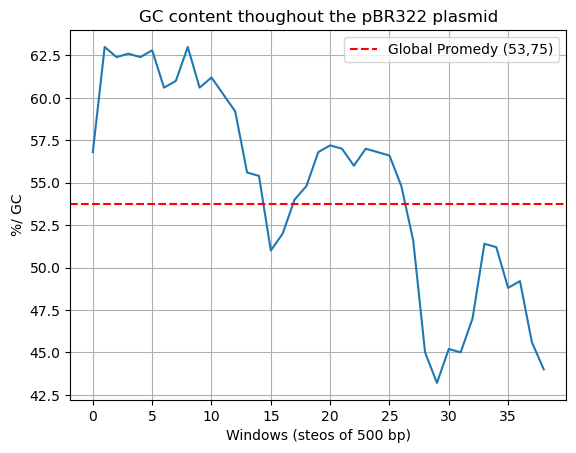

In [24]:
# Importing matplotlib
import matplotlib.pyplot as plt

plt.plot(gc_value)
plt.title("GC content thoughout the pBR322 plasmid")
plt.xlabel(f"Windows (steos of {window_size} bp)")
plt.ylabel("%/ GC")
plt.axhline(y=53.75, color='r', linestyle='--', label=f'Global Promedy (53,75)')
plt.legend()
plt.grid(True)

plt.show()